# Polars — Feature Showcase

**YZV 322E Applied Data Engineering · Spring 2026**

This notebook walks through every major Polars feature on real NYC Taxi data:

1. Reading from PostgreSQL (Pandas vs Polars+connectorx)
2. The eager API — method chaining and expressions
3. The lazy API and query plan optimization
4. The streaming engine for larger-than-RAM data
5. Pandas vs Polars benchmark on the same operations

**Prerequisite:** the `taxi_trips` table must already be loaded. If it isn't, open a terminal in the container and run:

```bash
docker compose exec app python data/load_taxi_data.py
```

## 0. Setup

In [2]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from sqlalchemy import create_engine

# Build the Postgres connection string from environment variables
PG_URI = (
    f"postgresql://{os.environ.get('POSTGRES_USER', 'polars')}:"
    f"{os.environ.get('POSTGRES_PASSWORD', 'polars_demo_2026')}@"
    f"{os.environ.get('POSTGRES_HOST', 'postgres')}:"
    f"{os.environ.get('POSTGRES_PORT', '5432')}/"
    f"{os.environ.get('POSTGRES_DB', 'taxi')}"
)

print(f"Polars version: {pl.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Connected to:   {PG_URI.split('@')[1]}")

Polars version: 1.40.1
Pandas version: 2.2.3
Connected to:   postgres:5432/taxi


---

## 1. Reading from PostgreSQL — Pandas vs Polars

### 1a. Pandas — single-threaded read via SQLAlchemy

In [2]:
QUERY = """
    SELECT pickup_datetime, dropoff_datetime, passenger_count,
           trip_distance, fare_amount, tip_amount, total_amount,
           pu_location_id, do_location_id, payment_type
    FROM taxi_trips
    WHERE pickup_datetime >= '2024-01-01'
      AND pickup_datetime <  '2024-02-01'
"""

engine = create_engine(PG_URI)

t0 = time.time()
df_pd = pd.read_sql(QUERY, engine)
pandas_read_time = time.time() - t0

print(f"  rows         : {len(df_pd):,}")
print(f"  memory       : {df_pd.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  elapsed time : {pandas_read_time:.2f}s")

  rows         : 2,964,606
  memory       : 237.2 MB
  elapsed time : 8.73s


### 1b. Polars — parallel read via connectorx


In [3]:
t0 = time.time()
df_pl = pl.read_database_uri(query=QUERY, uri=PG_URI, engine="connectorx")
polars_read_time = time.time() - t0

print(f"  rows         : {len(df_pl):,}")
print(f"  memory       : {df_pl.estimated_size('mb'):.1f} MB")
print(f"  elapsed time : {polars_read_time:.2f}s")

speedup = pandas_read_time / polars_read_time
print(f"\n  → Polars was {speedup:.1f}× faster on identical hardware and identical query")

  rows         : 2,964,606
  memory       : 226.5 MB
  elapsed time : 1.72s

  → Polars was 5.1× faster on identical hardware and identical query


In [4]:
df_pd.head()

,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,pu_location_id,do_location_id,payment_type
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,17.7,0.00,22.70,186,79,2
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,10.0,3.75,18.75,140,236,1
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,23.3,3.00,31.30,236,79,1
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,10.0,2.00,17.00,79,211,1
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,7.9,3.20,16.10,211,148,1


In [5]:
# Quick peek at the Polars DataFrame
df_pl.head()

pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,pu_location_id,do_location_id,payment_type
datetime[μs],datetime[μs],i64,f64,f64,f64,f64,i64,i64,i64
2024-01-31 08:37:45,2024-01-31 08:47:25,1,1.51,10.7,2.6,17.3,236,162,1
2024-01-31 08:16:53,2024-01-31 08:23:49,5,1.02,8.6,3.15,15.75,90,125,1
2024-01-31 08:55:49,2024-01-31 09:17:30,5,1.77,19.1,0.0,23.1,246,161,2
2024-01-31 08:13:06,2024-01-31 08:24:12,1,0.85,10.7,4.41,19.11,140,237,1
2024-01-31 08:34:47,2024-01-31 08:43:06,1,0.78,-9.3,0.0,-13.3,237,237,2


In [6]:
# Schema — notice the Arrow-backed types: Datetime, Float32, Int32, etc.
df_pl.schema

Schema([('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('dropoff_datetime', Datetime(time_unit='us', time_zone=None)),
        ('passenger_count', Int64),
        ('trip_distance', Float64),
        ('fare_amount', Float64),
        ('tip_amount', Float64),
        ('total_amount', Float64),
        ('pu_location_id', Int64),
        ('do_location_id', Int64),
        ('payment_type', Int64)])

---

## 2. The Eager API — method chaining

### 2a. Average fare-per-mile by hour of day

In [7]:
by_hour = (
    df_pl
    .filter(
        (pl.col("trip_distance") > 0.5)
        & (pl.col("fare_amount") > 0)
        & (pl.col("fare_amount") < 200)
    )
    .with_columns([
        (pl.col("fare_amount") / pl.col("trip_distance")).alias("fare_per_mile"),
        pl.col("pickup_datetime").dt.hour().alias("hour"),
    ])
    .group_by("hour")
    .agg([
        pl.col("fare_per_mile").mean().round(2).alias("avg_fare_per_mile"),
        pl.col("trip_distance").median().round(2).alias("median_distance"),
        pl.len().alias("trip_count"),
    ])
    .sort("hour")
)
by_hour

hour,avg_fare_per_mile,median_distance,trip_count
i8,f64,f64,u32
0,6.48,2.24,72193
1,6.68,2.1,48182
2,6.57,2.08,33193
3,6.57,2.21,21767
4,6.15,2.9,14580
…,…,…,…
19,7.32,1.76,170092
20,6.91,1.9,149149
21,6.74,2.0,150429


### 2b. Visualise the hourly pattern

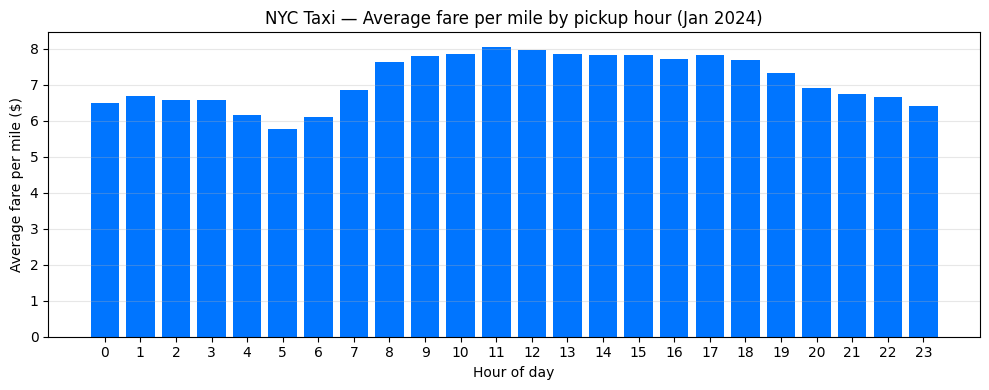

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour["hour"], by_hour["avg_fare_per_mile"], color="#0075FF")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average fare per mile ($)")
ax.set_title("NYC Taxi — Average fare per mile by pickup hour (Jan 2024)")
ax.set_xticks(range(24))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

## 3. The Lazy API — query plan optimization

**This is the most important concept in Polars.**

In [9]:
PARQUET_PATH = "/app/data/yellow_tripdata_2024-01.parquet"
assert Path(PARQUET_PATH).exists(), (
    f"Parquet file not found. Run the loader first:\n"
    f"  docker compose exec app python data/load_taxi_data.py"
)

# Build the query — nothing executes yet
lazy_query = (
    pl.scan_parquet(PARQUET_PATH)              # SCAN, not READ
    .filter(pl.col("trip_distance") > 1.0)
    .filter(pl.col("passenger_count") >= 1)
    .filter(pl.col("fare_amount") > 0)
    .select([
        "tpep_pickup_datetime",
        "trip_distance",
        "fare_amount",
        "tip_amount",
    ])
    .with_columns(
        pl.col("tpep_pickup_datetime").dt.hour().alias("hour")
    )
    .group_by("hour")
    .agg([
        pl.col("fare_amount").mean().alias("avg_fare"),
        pl.col("tip_amount").mean().alias("avg_tip"),
        pl.len().alias("trips"),
    ])
    .sort("hour")
)

print(f"Query type: {type(lazy_query).__name__}")
print("Nothing has been read or computed yet — this is just a plan.")

Query type: LazyFrame
Nothing has been read or computed yet — this is just a plan.


### 3a. The unoptimized plan — what we wrote

In [10]:
print(lazy_query.explain(optimized=False))

SORT BY [col("hour")]
  AGGREGATE[maintain_order: false]
    [col("fare_amount").mean().alias("avg_fare"), col("tip_amount").mean().alias("avg_tip"), len().alias("trips")] BY [col("hour")]
    FROM
     WITH_COLUMNS:
     [col("tpep_pickup_datetime").dt.hour().alias("hour")] 
      SELECT [col("tpep_pickup_datetime"), col("trip_distance"), col("fare_amount"), col("tip_amount")]
        FILTER [(col("fare_amount")) > (0.0)]
        FROM
          FILTER [(col("passenger_count")) >= (1)]
          FROM
            FILTER [(col("trip_distance")) > (1.0)]
            FROM
              Parquet SCAN [/app/data/yellow_tripdata_2024-01.parquet]
              PROJECT */19 COLUMNS
              ESTIMATED ROWS: 2964624


### 3b. The optimized plan — what Polars actually executes

In [11]:
print(lazy_query.explain(optimized=True))

SORT BY [col("hour")]
  AGGREGATE[maintain_order: false]
    [col("fare_amount").mean().alias("avg_fare"), col("tip_amount").mean().alias("avg_tip"), len().alias("trips")] BY [col("hour")]
    FROM
     WITH_COLUMNS:
     [col("tpep_pickup_datetime").dt.hour().alias("hour")] 
      simple π 3/3 ["tpep_pickup_datetime", ... 2 other columns]
        Parquet SCAN [/app/data/yellow_tripdata_2024-01.parquet]
        PROJECT 5/19 COLUMNS
        SELECTION: [([([(col("trip_distance")) > (1.0)]) & ([(col("passenger_count")) >= (1)])]) & ([(col("fare_amount")) > (0.0)])]
        ESTIMATED ROWS: 2964624


### 3c. Execute the plan

In [12]:
t0 = time.time()
result = lazy_query.collect()
lazy_time = time.time() - t0

print(f"Executed in {lazy_time:.3f}s")
result

Executed in 0.180s


hour,avg_fare,avg_tip,trips
i8,f64,f64,u32
0,22.669481,4.045779,55803
1,20.059011,3.653117,35807
2,18.845934,3.416942,25169
3,20.735998,3.504934,16199
4,26.331335,3.994834,10483
…,…,…,…
19,21.084305,4.153687,127118
20,21.155307,4.113359,115934
21,21.100512,4.132149,118711


---

## 4. The Streaming Engine — larger-than-RAM data

**To see this work on a larger dataset**, load multiple months first by running these in a terminal:

```bash
docker compose exec app python data/load_taxi_data.py --month 2024-02 --append
docker compose exec app python data/load_taxi_data.py --month 2024-03 --append
```

Open a separate terminal and run `docker stats` while the next cell runs — RAM stays flat.

In [3]:
data_dir = Path("/app/data")
parquet_files = sorted(data_dir.glob("yellow_tripdata_*.parquet"))
total_size_mb = sum(p.stat().st_size for p in parquet_files) / 1e6

print(f"Found {len(parquet_files)} file(s), total {total_size_mb:.0f} MB:")
for p in parquet_files:
    print(f"  - {p.name}  ({p.stat().st_size / 1e6:.0f} MB)")

Found 3 file(s), total 160 MB:
  - yellow_tripdata_2024-01.parquet  (50 MB)
  - yellow_tripdata_2024-02.parquet  (50 MB)
  - yellow_tripdata_2024-03.parquet  (60 MB)


In [4]:
# scan_parquet accepts a glob — Polars treats every matching file as one virtual table
streaming_query = (
    pl.scan_parquet(str(data_dir / "yellow_tripdata_*.parquet"))
    .filter(pl.col("fare_amount") > 0)
    .filter(pl.col("trip_distance") > 0)
    .group_by([
        pl.col("tpep_pickup_datetime").dt.month().alias("month"),
        "VendorID",
    ])
    .agg([
        pl.len().alias("trip_count"),
        pl.col("fare_amount").mean().round(2).alias("avg_fare"),
        pl.col("trip_distance").sum().round(0).alias("total_miles"),
        pl.col("total_amount").sum().round(0).alias("total_revenue"),
    ])
    .sort(["month", "VendorID"])
)

t0 = time.time()
streaming_result = streaming_query.collect(engine="streaming")
streaming_time = time.time() - t0

print(f"Streamed {total_size_mb:.0f} MB in {streaming_time:.2f}s\n")
streaming_result

Streamed 160 MB in 0.42s



month,VendorID,trip_count,avg_fare,total_miles,total_revenue
i8,i32,u32,f64,f64,f64
1,1,695641,17.47,2.16943e6,1.7968217e7
1,2,2173810,18.83,8.540455e6,6.0501408e7
1,6,260,46.9,2950.0,12401.0
2,1,693437,17.59,2.694681e6,1.8047742e7
2,2,2208044,18.68,8.794023e6,6.0990284e7
3,1,810187,18.22,3.196922e6,2.1545556e7
3,2,2629397,19.44,1.2702082e7,7.4288089e7
3,6,460,46.21,4659.0,21625.0
4,2,2,33.1,15.0,108.0


---

## 5. Pandas vs Polars Benchmark

In [ ]:
# We already have df_pd and df_pl from section 1. Reuse them.
print(f"Pandas DataFrame:  {len(df_pd):,} rows")
print(f"Polars DataFrame:  {len(df_pl):,} rows")

In [ ]:
def time_it(label, fn):
    t0 = time.time()
    fn()
    elapsed = time.time() - t0
    print(f"  {label:30s} {elapsed:6.3f}s")
    return elapsed

results = {}

# Already measured in section 1
results["Read from\nPostgres"] = (pandas_read_time, polars_read_time)

In [ ]:
# Benchmark: group-by + aggregate
print("Group-by + aggregate:")

def pandas_groupby():
    df_pd["hour"] = df_pd["pickup_datetime"].dt.hour
    return df_pd.groupby("hour").agg(
        avg_fare=("fare_amount", "mean"),
        total_tip=("tip_amount", "sum"),
        trip_count=("fare_amount", "count"),
    )

def polars_groupby():
    return (
        df_pl
        .with_columns(pl.col("pickup_datetime").dt.hour().alias("hour"))
        .group_by("hour")
        .agg([
            pl.col("fare_amount").mean().alias("avg_fare"),
            pl.col("tip_amount").sum().alias("total_tip"),
            pl.len().alias("trip_count"),
        ])
    )

pd_t = time_it("pandas", pandas_groupby)
pl_t = time_it("polars", polars_groupby)
results["Group-by\n+ aggregate"] = (pd_t, pl_t)

In [ ]:
# Benchmark: filter + sort top-N
print("Filter + sort top-N:")

def pandas_fs():
    return (
        df_pd[
            (df_pd["fare_amount"] > 10)
            & (df_pd["trip_distance"] > 2)
            & (df_pd["passenger_count"] >= 1)
        ]
        .sort_values("total_amount", ascending=False)
        .head(1000)
    )

def polars_fs():
    return (
        df_pl
        .filter(
            (pl.col("fare_amount") > 10)
            & (pl.col("trip_distance") > 2)
            & (pl.col("passenger_count") >= 1)
        )
        .sort("total_amount", descending=True)
        .head(1000)
    )

pd_t = time_it("pandas", pandas_fs)
pl_t = time_it("polars", polars_fs)
results["Filter\n+ sort top-N"] = (pd_t, pl_t)

In [ ]:
# Benchmark: aggregate + self-join
print("Aggregate + join:")

def pandas_join():
    summary = df_pd.groupby("pu_location_id", as_index=False).agg(
        zone_avg_fare=("fare_amount", "mean")
    )
    return df_pd.merge(summary, on="pu_location_id", how="left")

def polars_join():
    summary = (
        df_pl.group_by("pu_location_id")
        .agg(pl.col("fare_amount").mean().alias("zone_avg_fare"))
    )
    return df_pl.join(summary, on="pu_location_id", how="left")

pd_t = time_it("pandas", pandas_join)
pl_t = time_it("polars", polars_join)
results["Aggregate\n+ join"] = (pd_t, pl_t)

### 5a. Plot the results

In [ ]:
labels = list(results.keys())
pd_times = [results[k][0] for k in labels]
pl_times = [results[k][1] for k in labels]

fig, ax = plt.subplots(figsize=(11, 6))
x = list(range(len(labels)))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], pd_times, width, label="Pandas", color="#2C5F8D")
bars2 = ax.bar([i + width/2 for i in x], pl_times, width, label="Polars", color="#0075FF")

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}s",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)

for i, label in enumerate(labels):
    speedup = pd_times[i] / pl_times[i] if pl_times[i] > 0 else 0
    ax.text(i, max(pd_times[i], pl_times[i]) * 1.1,
            f"{speedup:.1f}× faster",
            ha="center", fontsize=10, fontweight="bold", color="#0075FF")

ax.set_ylabel("Time (seconds)")
ax.set_title("Pandas vs Polars  —  NYC Taxi Data (Jan 2024)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, max(max(pd_times), max(pl_times)) * 1.3)
plt.tight_layout()
plt.show()

---

## Summary

| Feature | Why it matters |
|---|---|
| **connectorx Postgres reader** | 5–10× faster than `pandas.read_sql` |
| **Eager API** | Method chaining, parallel by default |
| **Lazy API + optimizer** | Predicate / projection pushdown, smaller working sets |
| **Streaming engine** | Process datasets larger than RAM |
| **Apache Arrow memory** | Smaller footprint, zero-copy interop |

### Honest limitations

- Smaller ecosystem than Pandas — fewer Stack Overflow answers, fewer integrations
- API still evolving (1.0 reached in mid-2024)
- Not a drop-in replacement: requires rewriting code in expression syntax
- For tiny datasets (< 100K rows), Pandas may actually be slightly faster due to lower setup overhead

### Next: see the production ETL pipeline

This notebook is a feature showcase. For a realistic end-to-end ETL pipeline (Extract from Postgres → Transform with Polars → Load back to Postgres → Verify), see `src/etl_pipeline.py`:

```bash
docker compose exec app python src/05_etl_pipeline.py
```